In [2]:
import importlib
import torch
from collections import defaultdict, Counter
from torch_scatter import scatter_mean
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pickle

In [ ]:
from atomica.trainers.abs_trainer import Trainer
import atomica.models.masking_model
import atomica.data.dataset_pretrain
from atomica.data.pdb_utils import VOCAB
from atomica.utils.random_seed import setup_seed

In [4]:
sns.set_context("notebook")
custom_colors = ['#7B2EF7', '#26CFC0', '#E65AFA', '#078C95', '#133693', '#7EB4FF']

In [5]:
metal_elements = [
    'Li', 'Be', 'Na', 'Mg', 'Al', 'K', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 
    'Co', 'Ni', 'Cu', 'Zn', 'Ga', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Mo', 'Tc', 'Ru', 
    'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd', 'Pm', 
    'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta', 'W', 
    'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg', 'Tl', 'Pb', 'Bi', 'Po', 'Fr', 'Ra', 'Ac', 
    'Th', 'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md', 'No', 
    'Lr', 'Rf', 'Db', 'Sg', 'Bh', 'Hs', 'Mt', 'Ds', 'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 
    'Lv', 'Ts'
]

In [6]:
VOCAB.load_tokenizer('PS_300')
vocab_to_mask = VOCAB.aas + VOCAB.bases + VOCAB.sms + VOCAB.frags
block_type = sum([['amino acids'] * len(VOCAB.aas), ['nucleic acids'] * len(VOCAB.bases), ['small molecule fragments'] * (len(VOCAB.sms) + len(VOCAB.frags))], [])
for i, bt in enumerate(block_type):
    if vocab_to_mask[i][1] in metal_elements:
        block_type[i] = 'metal ion'

In [7]:
results_df = pd.DataFrame(columns=['id', 'CA_avg_distance', 'intra_distance', 'inter_distance', 'pred', 'label', 'seed'])
results_dir = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/masking/results/"
for modality in ['PDNA', 'PRNA', 'RNAL', 'Ppeptide', 'Pion', 'CSD', 'PP', 'PL']:
    fname = os.path.join(results_dir, f"{modality}.pkl")
    if os.path.exists(fname):
        print(f"Loading {modality} results")
        with open(fname, "rb") as f:
            model_ckpt, results, model1_ckpt, results1 = pickle.load(f) # results = id_list, preds_list, labels_list, CA_distances_list, intra_distances_list, inter_distances_list
        print(model_ckpt)
        print(model1_ckpt)
        print()
        for i, (id_list, preds_list, labels_list, CA_distances_list, intra_distances_list, inter_distances_list) in enumerate(results):
            results_df_i = pd.DataFrame(columns=['id', 'CA_avg_distance', 'intra_distance', 'inter_distance', 'probability', 'pred', 'label'])
            results_df_i['id'] = id_list
            results_df_i['CA_avg_distance'] = CA_distances_list
            results_df_i['intra_distance'] = intra_distances_list
            results_df_i['inter_distance'] = inter_distances_list
            results_df_i['probability'] = preds_list.tolist()
            results_df_i['pred'] = preds_list.argmax(dim=-1).tolist()
            results_df_i['label'] = labels_list.tolist()
            results_df_i['model'] = "Single Modality"
            results_df_i['modality'] = modality
            results_df_i['seed'] = i
            results_df = pd.concat([results_df, results_df_i])

        for i, (id_list, preds_list, labels_list, CA_distances_list, intra_distances_list, inter_distances_list) in enumerate(results1):
            results_df_i = pd.DataFrame(columns=['id', 'CA_avg_distance', 'intra_distance', 'inter_distance', 'probability', 'pred', 'label'])
            results_df_i['id'] = id_list
            results_df_i['CA_avg_distance'] = CA_distances_list
            results_df_i['intra_distance'] = intra_distances_list
            results_df_i['inter_distance'] = inter_distances_list
            results_df_i['pred'] = preds_list.argmax(dim=-1).tolist()
            results_df_i['probability'] = preds_list.tolist()
            results_df_i['label'] = labels_list.tolist()
            results_df_i['model'] = 'InteractNN'
            results_df_i['modality'] = modality
            results_df_i['seed'] = i
            results_df = pd.concat([results_df, results_df_i])
results_df['block_type'] = results_df['label'].apply(lambda x: block_type[x])

Loading PDNA results
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_1/checkpoint/epoch3_step1579.ckpt
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_7/checkpoint/epoch32_step14658.ckpt



/tmp/ipykernel_294711/2931962213.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, results_df_i])


Loading PRNA results
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_6/checkpoint/epoch2_step1213.ckpt
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_10/checkpoint/epoch6_step3153.ckpt

Loading RNAL results
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_2/checkpoint/epoch11_step732.ckpt
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_9/checkpoint/epoch32_step2013.ckpt



/tmp/ipykernel_294711/2931962213.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, results_df_i])
/tmp/ipykernel_294711/2931962213.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, results_df_i])
/tmp/ipykernel_294711/2931962213.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determini

Loading Ppeptide results
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_0/checkpoint/epoch27_step21672.ckpt
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_8/checkpoint/epoch30_step23608.ckpt

Loading Pion results
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_3/checkpoint/epoch132_step242991.ckpt
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_11/checkpoint/epoch29_step53897.ckpt

Loading CSD results
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_15/checkpoint/epoch15_step844000.ckpt
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_13/checkpoint/epoch4_step237376.ckpt



/tmp/ipykernel_294711/2931962213.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, results_df_i])
/tmp/ipykernel_294711/2931962213.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, results_df_i])
/tmp/ipykernel_294711/2931962213.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determini

Loading PP results
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-torsion/version_74/checkpoint/epoch28_step512630.ckpt
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_16/checkpoint/epoch20_step377727.ckpt

Loading PL results
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-torsion/version_73/checkpoint/epoch50_step606102.ckpt
/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/pretrain/models/InteractNN-masking/version_14/checkpoint/epoch55_step666112.ckpt



In [8]:
results_df['modality'].unique()

array(['PDNA', 'PRNA', 'RNAL', 'Ppeptide', 'Pion', 'CSD', 'PP', 'PL'],
      dtype=object)

In [9]:
results_df['correct'] = results_df['pred'] == results_df['label']
results_df

,id,CA_avg_distance,intra_distance,inter_distance,pred,label,seed,probability,model,modality,block_type,correct
0,5esp_1.pdb_5esp_1_DNA_C&D.pdb,5.307366,5.534056,11.200634,16,0,0,"[0.22353027760982513, 0.09078598022460938, 0.0...",Single Modality,PDNA,amino acids,False
1,5esp_1.pdb_5esp_1_DNA_C&D.pdb,6.131392,6.692351,14.592724,3,5,0,"[0.014224996790289879, 0.05280207097530365, 0....",Single Modality,PDNA,amino acids,False
2,5esp_1.pdb_5esp_1_DNA_C&D.pdb,6.417269,6.878589,12.797866,16,12,0,"[0.10057252645492554, 0.05833984538912773, 0.0...",Single Modality,PDNA,amino acids,False
3,5esp_1.pdb_5esp_1_DNA_C&D.pdb,6.867285,7.160176,14.220352,16,12,0,"[0.07863771170377731, 0.05106128752231598, 0.0...",Single Modality,PDNA,amino acids,False
4,5esp_1.pdb_5esp_1_DNA_C&D.pdb,6.863603,6.182571,15.452073,15,12,0,"[0.003523042891174555, 0.005826941225677729, 0...",Single Modality,PDNA,amino acids,False
...,...,...,...,...,...,...,...,...,...,...,...,...
26015,6pw5_1.pdb_6pw5_1_PIK_P.pdb,7.181817,6.983464,16.403595,7,7,4,"[1.555930282393092e-07, 2.1042564185336232e-05...",InteractNN,PL,amino acids,True
26016,6pw5_1.pdb_6pw5_1_PIK_P.pdb,6.811640,7.297763,12.586894,4,8,4,"[5.121759841131279e-06, 1.242813254975772e-06,...",InteractNN,PL,amino acids,False
26017,6pw5_1.pdb_6pw5_1_PIK_P.pdb,7.845710,8.037865,11.405678,2,2,4,"[0.017297929152846336, 0.06703554838895798, 0....",InteractNN,PL,amino acids,True
26018,6pw5_1.pdb_6pw5_1_PIK_P.pdb,NaN,10.038132,6.758039,211,211,4,"[7.611809996888041e-05, 1.1705254543414867e-08...",InteractNN,PL,small molecule fragments,True


In [10]:
baseline_results = results_df.groupby(['modality', 'block_type'])['label'].value_counts(normalize=True).reset_index(name='percentage')
agg_baseline_results = baseline_results.groupby(['modality', 'block_type'])['percentage'].agg(['mean', 'std']).reset_index()
frequency_baseline = baseline_results['percentage'].mean()
print(frequency_baseline)
agg_baseline_results

0.02555366269165247


,modality,block_type,mean,std
0,CSD,small molecule fragments,0.004695,0.011924
1,PDNA,amino acids,0.050000,0.027386
2,PDNA,nucleic acids,0.250000,0.011915
3,PL,amino acids,0.050000,0.023992
4,PL,metal ion,0.100000,0.276341
5,PL,small molecule fragments,0.004975,0.034830
6,PP,amino acids,0.050000,0.019586
7,PRNA,amino acids,0.050000,0.026085
8,PRNA,nucleic acids,0.125000,0.085341
9,Pion,amino acids,0.050000,0.032419


In [11]:
grouped_results = results_df.groupby(['modality', 'model', 'block_type', 'seed'])['correct'].agg(['mean', 'count'])
grouped_results = grouped_results.groupby(['modality', 'model', 'block_type'])[['mean', 'count']].agg(['mean', 'std'])
grouped_results

mean            \
                                                       mean       std   
modality model           block_type                                     
CSD      InteractNN      small molecule fragments  0.978697  0.000570   
         Single Modality small molecule fragments  0.978536  0.001124   
PDNA     InteractNN      amino acids               0.649644  0.003607   
                         nucleic acids             0.875518  0.015674   
         Single Modality amino acids               0.165451  0.005408   
                         nucleic acids             0.812332  0.017865   
PL       InteractNN      amino acids               0.670474  0.003158   
                         metal ion                 0.849631  0.065723   
                         small molecule fragments  0.916631  0.001617   
         Single Modality amino acids               0.654891  0.004148   
                         metal ion                 0.870915  0.053010   
                         small molecule fragments  0.910834  0.001568   
PP       InteractNN      amino acids               0.722962  0.001263   
         Single Modality amino acids               0.709087  0.002088   
PRNA     InteractNN      amino acids               0.545536  0.008241   
                         nucleic acids             0.538494  0.011062   
         Single Modality amino acids               0.146562  0.006081   
                         nucleic acids             0.430653  0.017358   
Pion     InteractNN      amino acids               0.782766  0.002302   
                         metal ion                 0.635702  0.015316   
         Single Modality amino acids               0.726365  0.004293   
                         metal ion                 0.575788  0.024527   
Ppeptide InteractNN      amino acids               0.616766  0.008026   
         Single Modality amino acids               0.354176  0.004520   
RNAL     InteractNN      metal ion                 0.871041  0.020427   
                         nucleic acids             0.719743  0.014248   
                         small molecule fragments  0.961477  0.020267   
         Single Modality metal ion                 0.843093  0.032029   
                         nucleic acids             0.502127  0.007666   
                         small molecule fragments  0.892391  0.044804   

                                                     count             
                                                      mean        std  
modality model           block_type                                    
CSD      InteractNN      small molecule fragments  11172.0   0.000000  
         Single Modality small molecule fragments  11172.0   0.000000  
PDNA     InteractNN      amino acids                1543.6   9.555103  
                         nucleic acids               714.4   9.555103  
         Single Modality amino acids                1543.6   9.555103  
                         nucleic acids               714.4   9.555103  
PL       InteractNN      amino acids               17235.6  12.778889  
                         metal ion                    54.4   8.080842  
                         small molecule fragments   8730.0  15.968719  
         Single Modality amino acids               17235.6  12.778889  
                         metal ion                    54.4   8.080842  
                         small molecule fragments   8730.0  15.968719  
PP       InteractNN      amino acids               76414.0   0.000000  
         Single Modality amino acids               76414.0   0.000000  
PRNA     InteractNN      amino acids                1136.4  13.649176  
                         nucleic acids               453.6  13.649176  
         Single Modality amino acids                1136.4  13.649176  
                         nucleic acids               453.6  13.649176  
Pion     InteractNN      amino acids                5054.4  21.582400  
                         metal ion                   537.6  2

In [12]:
from sklearn.metrics import average_precision_score

def calculate_auprc_multiclass(group):
    """Calculates AUPRC for each class for a given group of predictions and labels."""
    num_classes = len(group['probability'].values[0])
    y_true = np.zeros((len(group), num_classes))
    
    # One-hot encode the true labels for multiclass
    for i, label in enumerate(group['label']):
        y_true[i, label] = 1
    
    y_pred = np.stack(group['probability'].values)
    
    # Calculate AUPRC for each class (one-vs-rest)
    auprc_per_class = {}
    for class_idx in range(num_classes):
        if y_true[:, class_idx].sum() == 0:
            auprc_per_class[f'class_{class_idx}'] = pd.NA
        else:
            auprc_per_class[f'class_{class_idx}'] = average_precision_score(y_true[:, class_idx], y_pred[:, class_idx])
    
    return pd.Series(auprc_per_class)

def calculate_mean_auprc_multiclass(group):
    """Calculates AUPRC for each class for a given group of predictions and labels."""
    num_classes = len(group['probability'].values[0])
    y_true = np.zeros((len(group), num_classes))
    
    # One-hot encode the true labels for multiclass
    for i, label in enumerate(group['label']):
        y_true[i, label] = 1
    
    y_pred = np.stack(group['probability'].values)
    
    # Calculate AUPRC for each class (one-vs-rest)
    auprc_per_class = {}
    for class_idx in range(num_classes):
        if y_true[:, class_idx].sum() == 0:
            continue
        else:
            auprc_per_class[f'class_{class_idx}'] = average_precision_score(y_true[:, class_idx], y_pred[:, class_idx])
    
    mean_auprc = np.mean(list(auprc_per_class.values()))
    return pd.Series({'mean_auprc': mean_auprc})

# auprc_by_model = results_df.groupby(['modality', 'model']).apply(calculate_auprc_multiclass).reset_index()
auprc_by_model = results_df.groupby(['modality', 'model', 'seed']).apply(calculate_mean_auprc_multiclass).reset_index()
auprc_by_model

/tmp/ipykernel_294711/875101388.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  auprc_by_model = results_df.groupby(['modality', 'model', 'seed']).apply(calculate_mean_auprc_multiclass).reset_index()


,modality,model,seed,mean_auprc
0,CSD,InteractNN,0,0.966389
1,CSD,InteractNN,1,0.959467
2,CSD,InteractNN,2,0.956700
3,CSD,InteractNN,3,0.951263
4,CSD,InteractNN,4,0.956544
...,...,...,...,...
75,RNAL,Single Modality,0,0.600116
76,RNAL,Single Modality,1,0.630480
77,RNAL,Single Modality,2,0.565966
78,RNAL,Single Modality,3,0.623081


In [13]:
mean_auprc_by_model = auprc_by_model.groupby(['modality', 'model'])['mean_auprc'].agg(['mean', 'std']).reset_index()
mean_auprc_by_model

,modality,model,mean,std
0,CSD,InteractNN,0.958073,0.005516
1,CSD,Single Modality,0.957941,0.003047
2,PDNA,InteractNN,0.707017,0.013955
3,PDNA,Single Modality,0.242529,0.006529
4,PL,InteractNN,0.330928,0.004679
5,PL,Single Modality,0.307189,0.005085
6,PP,InteractNN,0.788490,0.001964
7,PP,Single Modality,0.773632,0.001990
8,PRNA,InteractNN,0.552446,0.007512
9,PRNA,Single Modality,0.187249,0.008431


Average AUPRC by modality


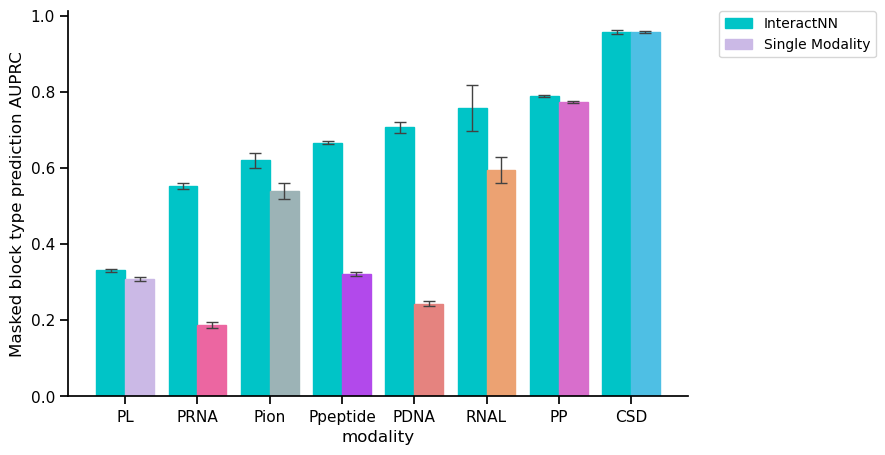

In [14]:
print("Average AUPRC by modality")

custom_colors = {
    'PRNA': '#EC66A1',
    'PDNA': '#E5837F',
    'RNAL': '#ECA272',
    'Ppeptide': '#B249EB',
    'Pion': '#9CB3B6',
    'CSD': '#4EBFE4',
    'PP': '#D86ECC',
    'PL': '#CBB9E6',
}
model_color = '#00C4C7'

plt.figure(figsize=(8,5))

interactnn_data = mean_auprc_by_model[mean_auprc_by_model['model'] == 'InteractNN']
sorted_modalities = interactnn_data.sort_values(by='mean')['modality'].tolist()
sns_plot = sns.barplot(
    x='modality', 
    y='mean', 
    hue='model', 
    data=mean_auprc_by_model, 
    order=sorted_modalities  # Pass the sorted order here
)

colors = [model_color for _ in range(len(sorted_modalities))] + [custom_colors[modality] for modality in sorted_modalities]
for i, bar in enumerate(sns_plot.patches):
    bar.set_color(colors[i])

# Step 4: Get unique models and number of bars per group
models = mean_auprc_by_model['model'].unique()
n_models = len(models)
bar_width = sns_plot.patches[0].get_width()  # width of a single bar

# Step 5: Align error bars with their respective bars
for i, model in enumerate(models):
    model_data = mean_auprc_by_model[mean_auprc_by_model['model'] == model]
    
    # Sort the model data by the same order of modalities
    model_data = model_data.set_index('modality').loc[sorted_modalities].reset_index()
    
    # Calculate the offset for each bar group
    offset = (i - (n_models - 1) / 2) * bar_width
    
    # Get the color of the current model's bars for error bars
    line_color = sns_plot.get_lines()[i].get_color()
    
    # Add error bars to the plot at the right positions
    plt.errorbar(
        x=np.arange(len(model_data['modality'])) + offset, 
        y=model_data['mean'], 
        yerr=model_data['std'], 
        fmt='none', 
        capsize=4, 
        elinewidth=1, 
        color=line_color
    )

# Step 6: Customize the plot
sns.despine()
plt.ylabel('Masked block type prediction AUPRC')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., prop={'size': 10})
plt.show()


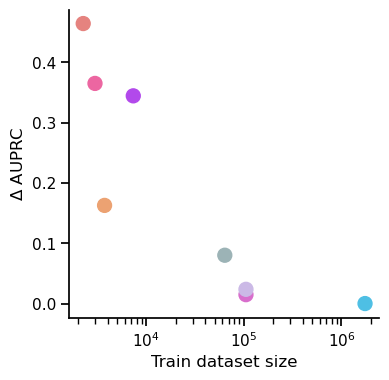

In [31]:
# dataset_size = { # this is all data
#     "CSD":1767710,
#     "PP":124541,
#     "PL":119017,
#     "Pion":74514,
#     "Ppeptide":8475,
#     "RNAL":5185,
#     "PRNA":3511,
#     "PDNA":2750,
# } 

dataset_size = { # training data only
    "CSD":1747710,
    "PP":105101,
    "PL":105090,
    "Pion":63767,
    "Ppeptide":7346,
    "RNAL":3730,
    "PRNA":2975,
    "PDNA":2253,
}

plt.figure(figsize=(4,4))

delta_improvement = []
for modality in dataset_size:
    if modality in mean_auprc_by_model['modality'].values:
        interactnn_auprc = mean_auprc_by_model[(mean_auprc_by_model['modality'] == modality) & (mean_auprc_by_model['model'] == 'InteractNN')]['mean'].values[0]
        single_modality_auprc = mean_auprc_by_model[(mean_auprc_by_model['modality'] == modality) & (mean_auprc_by_model['model'] == 'Single Modality')]['mean'].values[0]
        improvement = (interactnn_auprc - single_modality_auprc)
        delta_improvement.append([modality, improvement, interactnn_auprc - single_modality_auprc, dataset_size[modality]])
delta_improvement = pd.DataFrame(delta_improvement, columns=['modality', 'improvement', 'delta', 'dataset_size'])
delta_improvement['color'] = delta_improvement['modality'].apply(lambda x: custom_colors[x])

plt.scatter(delta_improvement['dataset_size'], delta_improvement['improvement'], c=delta_improvement['color'], s = 100)
plt.xlabel('Train dataset size')
plt.ylabel('$\Delta$ AUPRC')
plt.xscale('log')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [41]:
delta_improvement['dataset_size'] / delta_improvement['dataset_size'].sum()

0    0.857573
1    0.051571
2    0.051566
3    0.031289
4    0.003605
5    0.001830
6    0.001460
7    0.001106
Name: dataset_size, dtype: float64

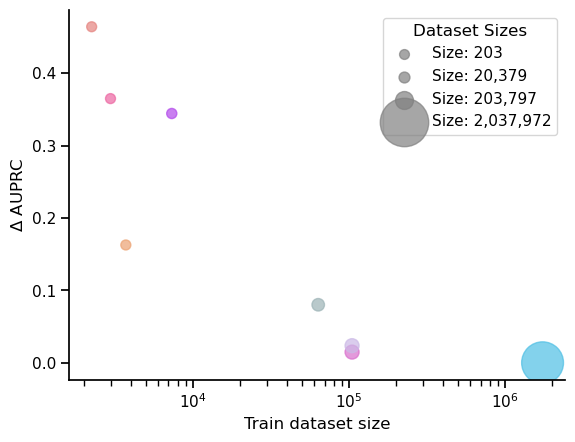

In [46]:
# Set a minimum size and scale from there
min_size = 50  # Minimum size for the smallest points
max_additional_size = 1000  # Maximum additional size beyond the minimum

# Calculate size with a guaranteed minimum
size_scaling = min_size + (delta_improvement['dataset_size'] / delta_improvement['dataset_size'].sum() * max_additional_size)

plt.scatter(delta_improvement['dataset_size'], delta_improvement['improvement'], 
           c=delta_improvement['color'], 
           s=size_scaling,  # This makes point size reflect dataset size with a minimum
           alpha=0.7)  # Adding some transparency can help when points overlap

plt.xlabel('Train dataset size')
plt.ylabel('$\Delta$ AUPRC')
plt.xscale('log')

# Update the size legend to reflect the new scaling
sizes = [0.0001*delta_improvement['dataset_size'].sum(), 0.01 * delta_improvement['dataset_size'].sum(), 0.1 * delta_improvement['dataset_size'].sum(), delta_improvement['dataset_size'].sum()]
labels = [f'{int(s):,}' for s in sizes]
for s, l in zip(sizes, labels):
    # Apply the same scaling as for the actual points
    scaled_size = min_size + (s / delta_improvement['dataset_size'].max() * max_additional_size)
    plt.scatter([], [], s=scaled_size, c='gray', alpha=0.7, label=f'Size: {l}')
plt.legend(title="Dataset Sizes", scatterpoints=1)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [16]:
delta_improvement.sort_values(by='improvement', ascending=False)

,modality,improvement,delta,dataset_size,color
6,PRNA,2.950321,0.365196,2975,#EC66A1
7,PDNA,2.915184,0.464488,2253,#E5837F
4,Ppeptide,2.071439,0.344605,7346,#B249EB
5,RNAL,1.273821,0.162903,3730,#ECA272
3,Pion,1.148581,0.080267,63767,#9CB3B6
2,PL,1.077277,0.023739,105090,#CBB9E6
1,PP,1.019205,0.014858,105101,#D86ECC
0,CSD,1.000137,0.000131,1747710,#4EBFE4


Average accuracy by modality


<ErrorbarContainer object of 3 artists>

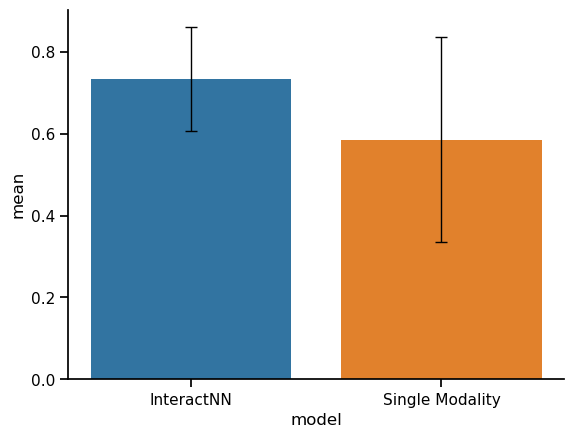

In [17]:
print("Average accuracy by modality")
ave_acc = results_df.groupby(['model', 'modality'])['correct'].mean().reset_index().groupby('model')['correct'].agg(['mean', 'std']).reset_index()
sns.barplot(x='model', y='mean', data=ave_acc)
sns.despine()
plt.errorbar(x=range(len(ave_acc['model'])), y=ave_acc['mean'], yerr=ave_acc['std'], fmt='none', capsize=4, elinewidth=1, color='black')

Average accuracy by modality


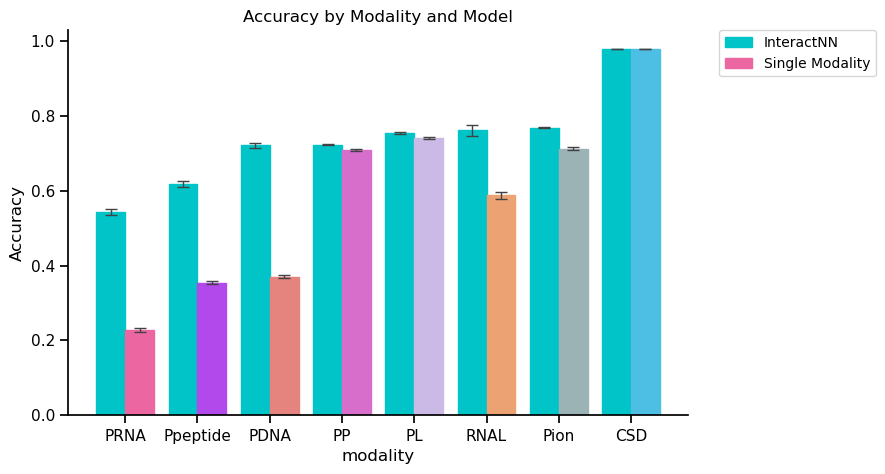

In [18]:
print("Average accuracy by modality")

custom_colors = {
    'PRNA': '#EC66A1',
    'PDNA': '#E5837F',
    'RNAL': '#ECA272',
    'Ppeptide': '#B249EB',
    'Pion': '#9CB3B6',
    'CSD': '#4EBFE4',
    'PP': '#D86ECC',
    'PL': '#CBB9E6',
}
model_color = '#00C4C7'

plt.figure(figsize=(8,5))

ave_acc_by_modality = results_df.groupby(['modality', 'model', 'seed'])['correct'].mean().reset_index().groupby(['modality', 'model'])['correct'].agg(['mean', 'std']).reset_index()

# Step 1: Filter data to get the 'InteractNN' accuracy
interactnn_data = ave_acc_by_modality[ave_acc_by_modality['model'] == 'InteractNN']

# Step 2: Sort the modalities based on the mean accuracy of 'InteractNN'
sorted_modalities = interactnn_data.sort_values(by='mean')['modality'].tolist()

# Step 3: Update the sns.barplot to use the sorted modalities
sns_plot = sns.barplot(
    x='modality', 
    y='mean', 
    hue='model', 
    data=ave_acc_by_modality, 
    # palette=custom_colors, 
    order=sorted_modalities  # Pass the sorted order here
)

colors = [model_color for _ in range(len(sorted_modalities))] + [custom_colors[modality] for modality in sorted_modalities]
for i, bar in enumerate(sns_plot.patches):
    bar.set_color(colors[i])

# Step 4: Get unique models and number of bars per group
models = ave_acc_by_modality['model'].unique()
n_models = len(models)
bar_width = sns_plot.patches[0].get_width()  # width of a single bar

# Step 5: Align error bars with their respective bars
for i, model in enumerate(models):
    model_data = ave_acc_by_modality[ave_acc_by_modality['model'] == model]
    
    # Sort the model data by the same order of modalities
    model_data = model_data.set_index('modality').loc[sorted_modalities].reset_index()
    
    # Calculate the offset for each bar group
    offset = (i - (n_models - 1) / 2) * bar_width
    
    # Get the color of the current model's bars for error bars
    line_color = sns_plot.get_lines()[i].get_color()
    
    # Add error bars to the plot at the right positions
    plt.errorbar(
        x=np.arange(len(model_data['modality'])) + offset, 
        y=model_data['mean'], 
        yerr=model_data['std'], 
        fmt='none', 
        capsize=4, 
        elinewidth=1, 
        color=line_color
    )

# Step 6: Customize the plot
sns.despine()
plt.ylabel('Accuracy')
plt.title('Accuracy by Modality and Model')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., prop={'size': 10})
plt.show()


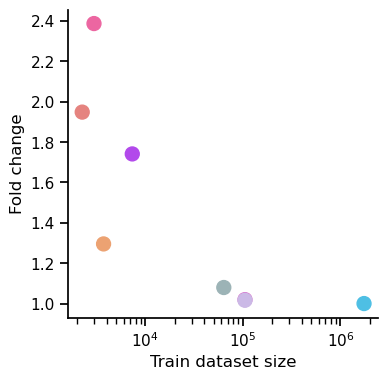

In [19]:
# dataset_size = { # this is all data
#     "CSD":1767710,
#     "PP":124541,
#     "PL":119017,
#     "Pion":74514,
#     "Ppeptide":8475,
#     "RNAL":5185,
#     "PRNA":3511,
#     "PDNA":2750,
# } 

dataset_size = { # training data only
    "CSD":1747710,
    "PP":105101,
    "PL":105090,
    "Pion":63767,
    "Ppeptide":7346,
    "RNAL":3730,
    "PRNA":2975,
    "PDNA":2253,
}

plt.figure(figsize=(4,4))

delta_improvement = []
for modality in dataset_size:
    if modality in ave_acc_by_modality['modality'].values:
        interactnn_auprc = ave_acc_by_modality[(ave_acc_by_modality['modality'] == modality) & (ave_acc_by_modality['model'] == 'InteractNN')]['mean'].values[0]
        single_modality_auprc = ave_acc_by_modality[(ave_acc_by_modality['modality'] == modality) & (ave_acc_by_modality['model'] == 'Single Modality')]['mean'].values[0]
        improvement = (interactnn_auprc - single_modality_auprc) / single_modality_auprc + 1
        delta_improvement.append([modality, improvement, interactnn_auprc - single_modality_auprc, dataset_size[modality]])
delta_improvement = pd.DataFrame(delta_improvement, columns=['modality', 'improvement', 'delta', 'dataset_size'])
delta_improvement['color'] = delta_improvement['modality'].apply(lambda x: custom_colors[x])

plt.scatter(delta_improvement['dataset_size'], delta_improvement['improvement'], c=delta_improvement['color'], s = 100)
plt.xlabel('Train dataset size')
plt.ylabel('Fold change')
plt.xscale('log')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [20]:
print("Delta improvement on accuracy metric")
delta_improvement.sort_values(by='improvement', ascending=False)

Delta improvement on accuracy metric


,modality,improvement,delta,dataset_size,color
6,PRNA,2.387293,0.315849,2975,#EC66A1
7,PDNA,1.948540,0.351019,2253,#E5837F
4,Ppeptide,1.741413,0.262591,7346,#B249EB
5,RNAL,1.295555,0.173679,3730,#ECA272
3,Pion,1.079628,0.056688,63767,#9CB3B6
1,PP,1.019567,0.013874,105101,#D86ECC
2,PL,1.016499,0.012229,105090,#CBB9E6
0,CSD,1.000165,0.000161,1747710,#4EBFE4


/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


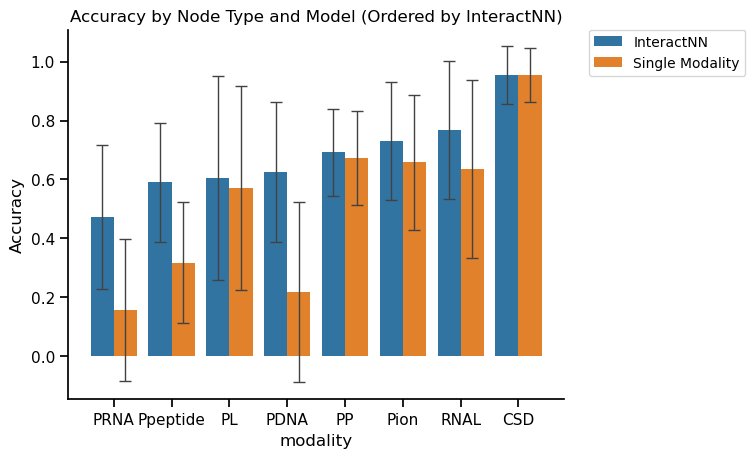

In [21]:
# Group by modality, model, label, and seed, and filter for those with count > 10
min_count = results_df.groupby(['modality', 'model', 'label', 'seed'])['correct'].count() > 10

# Calculate average accuracy by class and then group by modality and model
ave_acc_by_class = (
    results_df.groupby(['modality', 'model', 'label', 'seed'])['correct'].mean()[min_count]
    .reset_index()
    .groupby(['modality', 'model'])['correct']
    .agg(['mean', 'std'])
    .reset_index()
)

# Filter the DataFrame for InteractNN model, then order modalities by mean accuracy
interactnn_order = (
    ave_acc_by_class[ave_acc_by_class['model'] == 'InteractNN']
    .sort_values(by='mean', ascending=True)['modality']
    .tolist()
)

# Update modality column to categorical for ordered plotting
ave_acc_by_class['modality'] = pd.Categorical(
    ave_acc_by_class['modality'], categories=interactnn_order, ordered=True
)

# Create the plot
sns_plot = sns.barplot(x='modality', y='mean', hue='model', data=ave_acc_by_class)

# Get bar width for offset calculation
bar_width = sns_plot.patches[0].get_width()
n_models = ave_acc_by_class['model'].nunique()

# Iterate over models and plot error bars
for i, model in enumerate(ave_acc_by_class['model'].unique()):
    model_data = ave_acc_by_class[ave_acc_by_class['model'] == model]
    # Make sure to match the x positions with the new ordered modalities
    model_data = model_data.set_index('modality').loc[interactnn_order].reset_index()
    
    offset = (i - (n_models - 1) / 2) * bar_width
    line_color = sns_plot.get_lines()[i].get_color()
    plt.errorbar(
        x=np.arange(len(model_data['modality'])) + offset,  # Use the correct order for x
        y=model_data['mean'],
        yerr=model_data['std'],
        fmt='none', capsize=4, elinewidth=1, color=line_color
    )

# Finalize the plot
sns.despine()
plt.ylabel('Accuracy')
plt.title('Accuracy by Node Type and Model (Ordered by InteractNN)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., prop={'size': 10})

# Show the plot
plt.show()


Class level average accuracy


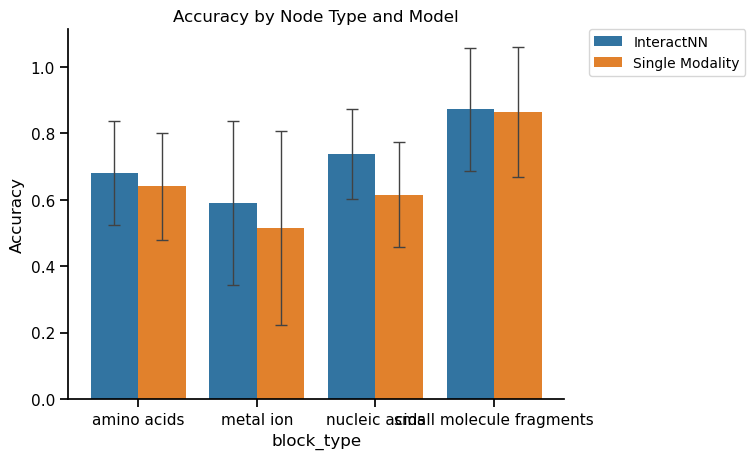

In [22]:
min_count = results_df.groupby(['block_type', 'model', 'label', 'seed'])['correct'].count() > 10
print("Class level average accuracy")
ave_acc_by_class = results_df.groupby(['block_type', 'model', 'label', 'seed'])['correct'].mean()[min_count].reset_index().groupby(['block_type', 'model'])['correct'].agg(['mean', 'std']).reset_index()
sns_plot = sns.barplot(x='block_type', y='mean', hue='model', data=ave_acc_by_class)

bar_width = sns_plot.patches[0].get_width()  # width of a single bar
n_models = ave_acc_by_class['model'].nunique()
bar_positions = []
for i, patch in enumerate(sns_plot.patches):
    bar_positions.append(patch.get_x() + patch.get_width() / 2)
for i, model in enumerate(ave_acc_by_class['model'].unique()):
    model_data = ave_acc_by_class[ave_acc_by_class['model'] == model]
    offset = (i - (n_models - 1) / 2) * bar_width
    line_color = sns_plot.get_lines()[i].get_color()
    plt.errorbar(x=np.arange(len(model_data['block_type'])) + offset, y=model_data['mean'], yerr=model_data['std'], fmt='none', capsize=4, elinewidth=1, color=line_color)
sns.despine()
plt.ylabel('Accuracy')
plt.title('Accuracy by Node Type and Model')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., prop={'size': 10})
plt.show()


/tmp/ipykernel_294711/3551956992.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  CA_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'modality', 'seed'])['correct'].mean().reset_index()
/tmp/ipykernel_294711/3551956992.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  CA_accuracy_per_bin = CA_accuracy_per_bin.groupby(['distance_bin_mid', 'model', 'modality'])['correct'].agg(['mean', 'std']).reset_index() # mean, std accuracy across seeds
/tmp/ipykernel_294711/3551956992.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pa

<Axes: xlabel='distance_bin_mid', ylabel='correct'>

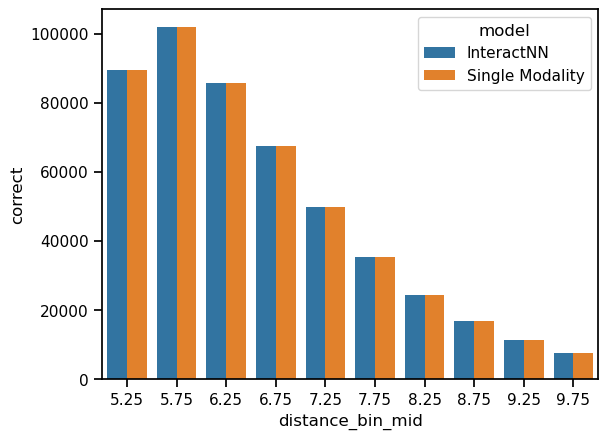

In [23]:
# Define bins for CA_avg_distance
bins = np.arange(5, 10.5, 0.5)
df_clean = results_df.dropna(subset=['CA_avg_distance']).copy()
df_clean['distance_bin'] = pd.cut(df_clean['CA_avg_distance'], bins=bins)
df_clean['distance_bin_mid'] = df_clean['distance_bin'].apply(lambda x: x.mid)
CA_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'modality', 'seed'])['correct'].mean().reset_index()
CA_accuracy_per_bin = CA_accuracy_per_bin.groupby(['distance_bin_mid', 'model', 'modality'])['correct'].agg(['mean', 'std']).reset_index() # mean, std accuracy across seeds
CA_accuracy_per_bin = CA_accuracy_per_bin.groupby(['distance_bin_mid', 'model'])[['mean', 'std']].agg(['mean']).reset_index() # mean accuracy across modalities and mean std across modalities
CA_accuracy_per_bin.columns = CA_accuracy_per_bin.columns.droplevel(1)
# CA_accuracy_per_bin = CA_accuracy_per_bin.groupby(['distance_bin_mid', 'model'])['correct'].agg(['mean', 'std']).reset_index()

CA_auprc_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'modality', 'seed']).apply(calculate_mean_auprc_multiclass).reset_index()
CA_auprc_per_bin = CA_auprc_per_bin.groupby(['distance_bin_mid', 'model', 'modality'])['mean_auprc'].agg(['mean', 'std']).reset_index() # mean, std AUPRC across seeds
CA_auprc_per_bin = CA_auprc_per_bin.groupby(['distance_bin_mid', 'model'])[['mean', 'std']].agg(['mean']).reset_index() # mean AUPRC across modalities and mean std across modalities
CA_auprc_per_bin.columns = CA_auprc_per_bin.columns.droplevel(1)

counts_per_bin = df_clean.groupby(['distance_bin_mid', 'model'])['correct'].count().reset_index()
sns.barplot(x='distance_bin_mid', y='correct', hue='model', data=counts_per_bin)

/tmp/ipykernel_294711/1027453041.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inter_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'modality', 'seed'])['correct'].mean().reset_index()
/tmp/ipykernel_294711/1027453041.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inter_accuracy_per_bin = inter_accuracy_per_bin.groupby(['distance_bin_mid', 'model', 'modality'])['correct'].agg(['mean', 'std']).reset_index()
/tmp/ipykernel_294711/1027453041.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False

<Axes: xlabel='distance_bin_mid', ylabel='correct'>

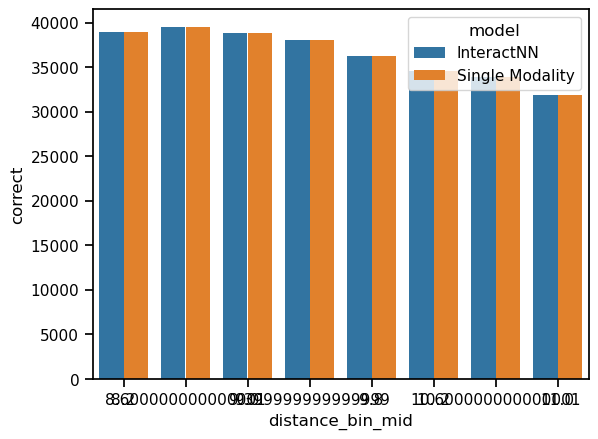

In [24]:
# Define bins for inter_distance
bins = np.arange(8, 11.5, 0.4)
df_clean = results_df.dropna(subset=['inter_distance']).copy()
df_clean['distance_bin'] = pd.cut(df_clean['inter_distance'], bins=bins)
df_clean['distance_bin_mid'] = df_clean['distance_bin'].apply(lambda x: x.mid)
inter_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'modality', 'seed'])['correct'].mean().reset_index()
inter_accuracy_per_bin = inter_accuracy_per_bin.groupby(['distance_bin_mid', 'model', 'modality'])['correct'].agg(['mean', 'std']).reset_index()
inter_accuracy_per_bin = inter_accuracy_per_bin.groupby(['distance_bin_mid', 'model'])[['mean', 'std']].agg(['mean']).reset_index()
inter_accuracy_per_bin.columns = inter_accuracy_per_bin.columns.droplevel(1)

inter_AUPRC_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'modality', 'seed']).apply(calculate_mean_auprc_multiclass).reset_index()
inter_AUPRC_per_bin = inter_AUPRC_per_bin.groupby(['distance_bin_mid', 'model', 'modality'])['mean_auprc'].agg(['mean', 'std']).reset_index() # mean, std AUPRC across seeds
inter_AUPRC_per_bin = inter_AUPRC_per_bin.groupby(['distance_bin_mid', 'model'])[['mean', 'std']].agg(['mean']).reset_index() # mean AUPRC across modalities and mean std across modalities
inter_AUPRC_per_bin.columns = inter_AUPRC_per_bin.columns.droplevel(1)

counts_per_bin = df_clean.groupby(['distance_bin_mid', 'model'])['correct'].count().reset_index()
sns.barplot(x='distance_bin_mid', y='correct', hue='model', data=counts_per_bin)

/tmp/ipykernel_294711/3302658501.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  intra_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'modality', 'seed'])['correct'].mean().reset_index()
/tmp/ipykernel_294711/3302658501.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  intra_accuracy_per_bin = intra_accuracy_per_bin.groupby(['distance_bin_mid', 'model', 'modality'])['correct'].agg(['mean', 'std']).reset_index()
/tmp/ipykernel_294711/3302658501.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False

<Axes: xlabel='distance_bin_mid', ylabel='correct'>

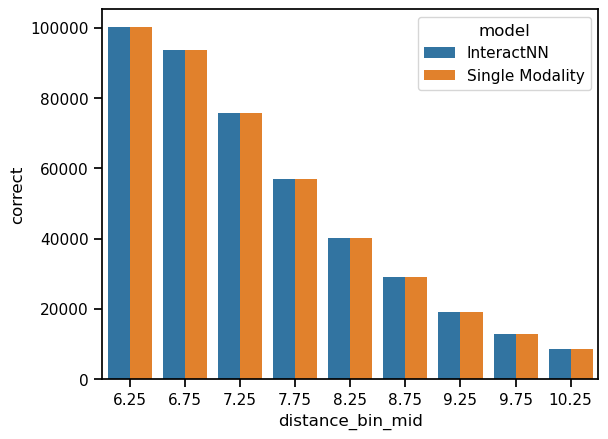

In [25]:
# Define bins for intra_distance
bins = np.arange(6, 11, 0.5)
df_clean = results_df.dropna(subset=['intra_distance']).copy()
df_clean['distance_bin'] = pd.cut(df_clean['intra_distance'], bins=bins)
df_clean['distance_bin_mid'] = df_clean['distance_bin'].apply(lambda x: x.mid)
intra_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'modality', 'seed'])['correct'].mean().reset_index()
intra_accuracy_per_bin = intra_accuracy_per_bin.groupby(['distance_bin_mid', 'model', 'modality'])['correct'].agg(['mean', 'std']).reset_index()
intra_accuracy_per_bin = intra_accuracy_per_bin.groupby(['distance_bin_mid', 'model'])[['mean', 'std']].agg(['mean']).reset_index()
intra_accuracy_per_bin.columns = intra_accuracy_per_bin.columns.droplevel(1)

intra_AUPRC_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'modality', 'seed']).apply(calculate_mean_auprc_multiclass).reset_index()
intra_AUPRC_per_bin = intra_AUPRC_per_bin.groupby(['distance_bin_mid', 'model', 'modality'])['mean_auprc'].agg(['mean', 'std']).reset_index() # mean, std AUPRC across seeds
intra_AUPRC_per_bin = intra_AUPRC_per_bin.groupby(['distance_bin_mid', 'model'])[['mean', 'std']].agg(['mean']).reset_index() # mean AUPRC across modalities and mean std across modalities
intra_AUPRC_per_bin.columns = intra_AUPRC_per_bin.columns.droplevel(1)

counts_per_bin = df_clean.groupby(['distance_bin_mid', 'model'])['correct'].count().reset_index()
sns.barplot(x='distance_bin_mid', y='correct', hue='model', data=counts_per_bin)

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/

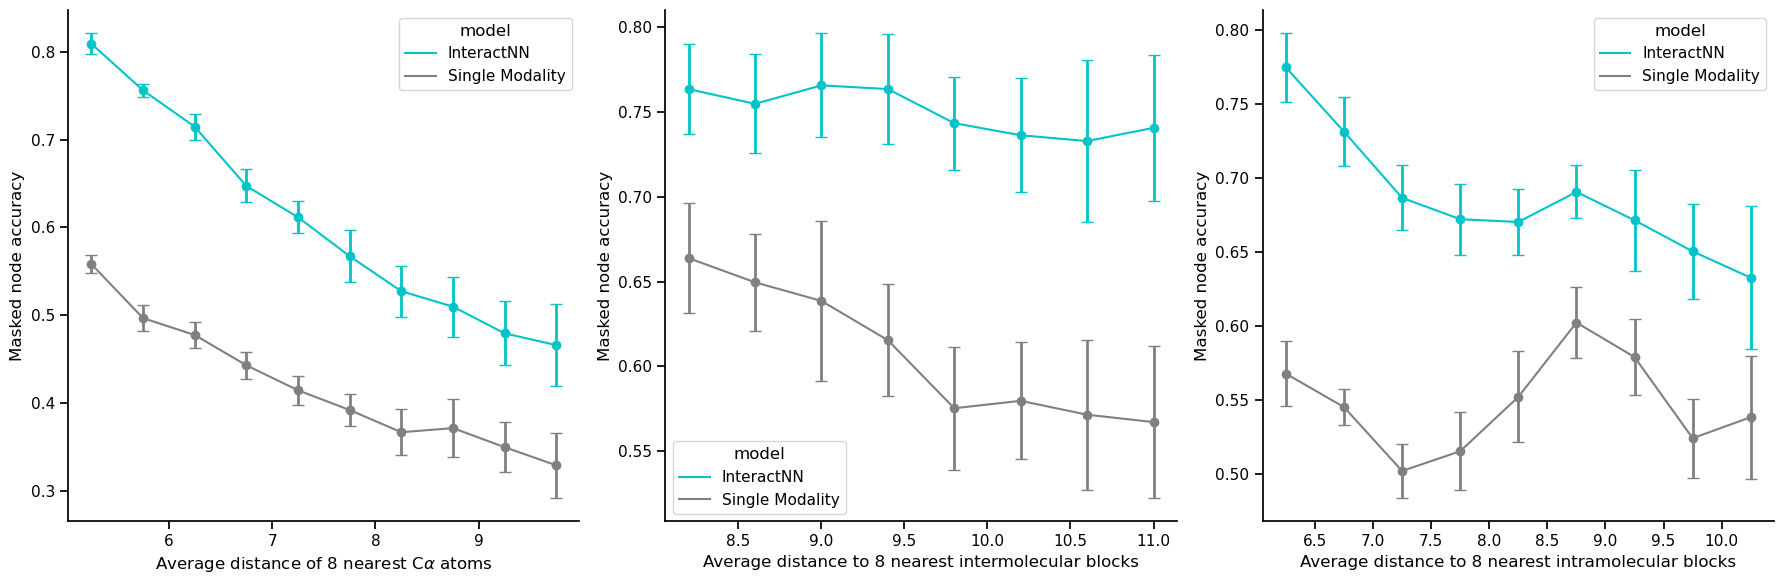

In [26]:
model_custom_colors = {
    'InteractNN': '#00C4C7',
    'Single Modality': '#808080',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns_plot = sns.lineplot(x='distance_bin_mid', y='mean', hue='model', data=CA_accuracy_per_bin, marker="o", ax=axes[0], palette=model_custom_colors)
for i, model in enumerate(CA_accuracy_per_bin['model'].unique()):
    model_data = CA_accuracy_per_bin[CA_accuracy_per_bin['model'] == model]
    line_color = sns_plot.get_lines()[i].get_color()
    axes[0].errorbar(x=model_data['distance_bin_mid'], y=model_data['mean'], yerr=model_data['std'], fmt='o', capsize=4, elinewidth=2, color=line_color)
axes[0].set_xlabel(r'Average distance of 8 nearest C$\alpha$ atoms')
axes[0].set_ylabel('Masked node accuracy')

sns_plot = sns.lineplot(x='distance_bin_mid', y='mean', hue='model', data=inter_accuracy_per_bin, marker="o", ax=axes[1], palette=model_custom_colors)
for i, model in enumerate(inter_accuracy_per_bin['model'].unique()):
    model_data = inter_accuracy_per_bin[inter_accuracy_per_bin['model'] == model]
    line_color = sns_plot.get_lines()[i].get_color()
    axes[1].errorbar(x=model_data['distance_bin_mid'], y=model_data['mean'], yerr=model_data['std'], fmt='o', capsize=4, elinewidth=2, color=line_color)
axes[1].set_xlabel('Average distance to 8 nearest intermolecular blocks')
axes[1].set_ylabel('Masked node accuracy')

sns_plot = sns.lineplot(x='distance_bin_mid', y='mean', hue='model', data=intra_accuracy_per_bin, marker="o", ax=axes[2], palette=model_custom_colors)
for i, model in enumerate(intra_accuracy_per_bin['model'].unique()):
    model_data = intra_accuracy_per_bin[intra_accuracy_per_bin['model'] == model]
    line_color = sns_plot.get_lines()[i].get_color()
    axes[2].errorbar(x=model_data['distance_bin_mid'], y=model_data['mean'], yerr=model_data['std'], fmt='o', capsize=4, elinewidth=2, color=line_color)
axes[2].set_xlabel('Average distance to 8 nearest intramolecular blocks')
axes[2].set_ylabel('Masked node accuracy')

sns.despine()
plt.subplots_adjust(top=0.9)
plt.tight_layout()
plt.show()

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/

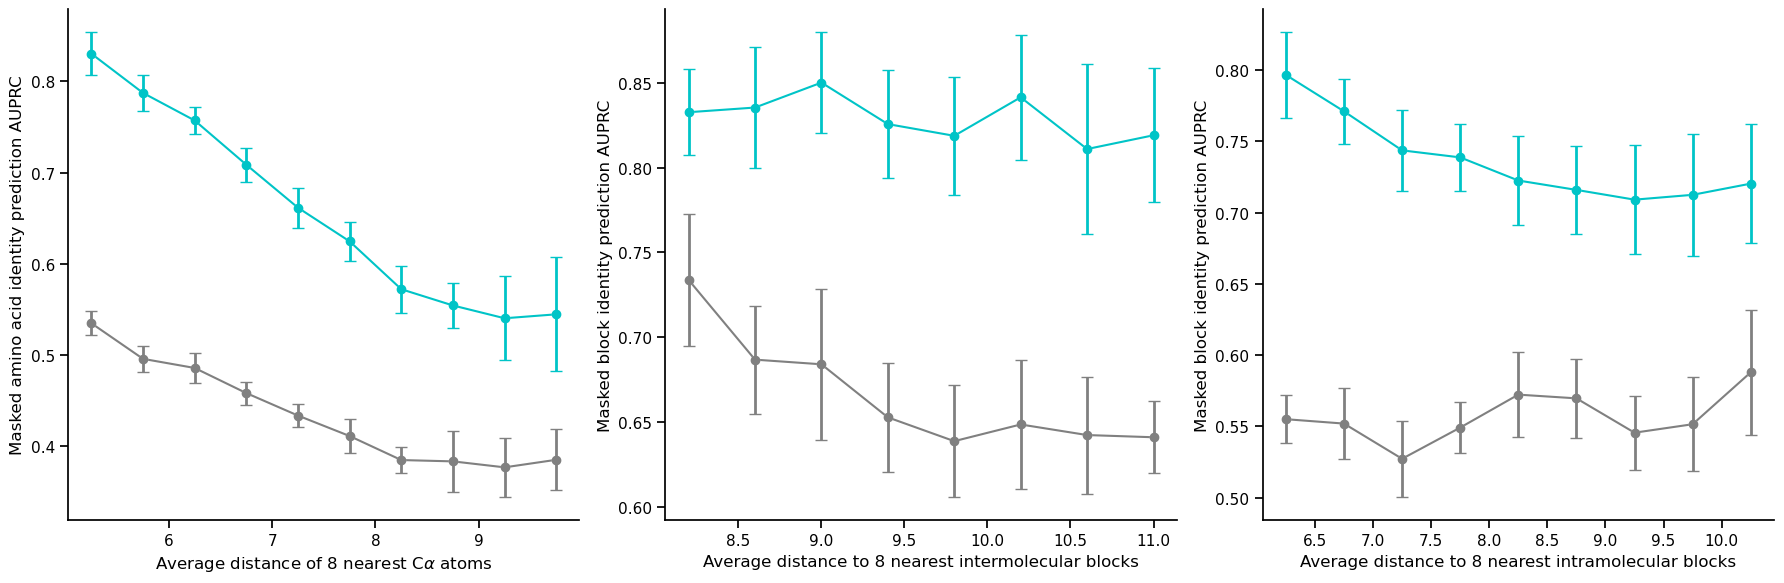

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns_plot = sns.lineplot(x='distance_bin_mid', y='mean', hue='model', data=CA_auprc_per_bin, marker="o", ax=axes[0], palette=model_custom_colors, legend=False)
for i, model in enumerate(CA_auprc_per_bin['model'].unique()):
    model_data = CA_auprc_per_bin[CA_auprc_per_bin['model'] == model]
    line_color = sns_plot.get_lines()[i].get_color()
    axes[0].errorbar(x=model_data['distance_bin_mid'], y=model_data['mean'], yerr=model_data['std'], fmt='o', capsize=4, elinewidth=2, color=line_color)
axes[0].set_xlabel(r'Average distance of 8 nearest C$\alpha$ atoms')
axes[0].set_ylabel('Masked amino acid identity prediction AUPRC')

sns_plot = sns.lineplot(x='distance_bin_mid', y='mean', hue='model', data=inter_AUPRC_per_bin, marker="o", ax=axes[1], palette=model_custom_colors, legend=False)
for i, model in enumerate(inter_AUPRC_per_bin['model'].unique()):
    model_data = inter_AUPRC_per_bin[inter_AUPRC_per_bin['model'] == model]
    line_color = sns_plot.get_lines()[i].get_color()
    axes[1].errorbar(x=model_data['distance_bin_mid'], y=model_data['mean'], yerr=model_data['std'], fmt='o', capsize=4, elinewidth=2, color=line_color)
axes[1].set_xlabel('Average distance to 8 nearest intermolecular blocks')
axes[1].set_ylabel('Masked block identity prediction AUPRC')

sns_plot = sns.lineplot(x='distance_bin_mid', y='mean', hue='model', data=intra_AUPRC_per_bin, marker="o", ax=axes[2], palette=model_custom_colors, legend=False)
for i, model in enumerate(intra_AUPRC_per_bin['model'].unique()):
    model_data = intra_AUPRC_per_bin[intra_AUPRC_per_bin['model'] == model]
    line_color = sns_plot.get_lines()[i].get_color()
    axes[2].errorbar(x=model_data['distance_bin_mid'], y=model_data['mean'], yerr=model_data['std'], fmt='o', capsize=4, elinewidth=2, color=line_color)
axes[2].set_xlabel('Average distance to 8 nearest intramolecular blocks')
axes[2].set_ylabel('Masked block identity prediction AUPRC')

sns.despine()
plt.subplots_adjust(top=0.9)
plt.tight_layout()
plt.show()

In [28]:
inter_AUPRC_per_bin_model = inter_AUPRC_per_bin.pivot_table(
    index='distance_bin_mid', 
    columns='model', 
    values='mean'
)
inter_AUPRC_per_bin_model['improvement'] = (inter_AUPRC_per_bin_model['InteractNN'] - inter_AUPRC_per_bin_model['Single Modality']) / inter_AUPRC_per_bin_model['Single Modality']
inter_AUPRC_per_bin_model

/tmp/ipykernel_294711/476026588.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  inter_AUPRC_per_bin_model = inter_AUPRC_per_bin.pivot_table(


model,InteractNN,Single Modality,improvement
distance_bin_mid,,,
8.2,0.832564,0.733787,0.134612
8.6,0.835315,0.686845,0.216162
9.0,0.850005,0.684108,0.242501
9.4,0.825563,0.652858,0.264537
9.8,0.818663,0.638837,0.281489
10.2,0.841346,0.648671,0.297030
10.6,0.810873,0.642437,0.262183
11.0,0.818986,0.641137,0.277396


Improvement of blocks closest to other intramolecular blocks v.s. blocks furthest from other intramolecular blocks

In [29]:
(0.796506-0.720268)/0.720268

0.1058467126125276

# For each block type
We need to highlight more the modalities with less data, produce a plot split by modality? 
e.g. nucleic blocks, protien blocks, ligand blocks?

/tmp/ipykernel_294711/2397038613.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inter_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'seed'])['correct'].mean().reset_index()
/tmp/ipykernel_294711/2397038613.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inter_accuracy_per_bin = inter_accuracy_per_bin.groupby(['distance_bin_mid', 'model'])['correct'].agg(['mean', 'std']).reset_index()
/tmp/ipykernel_294711/2397038613.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beha

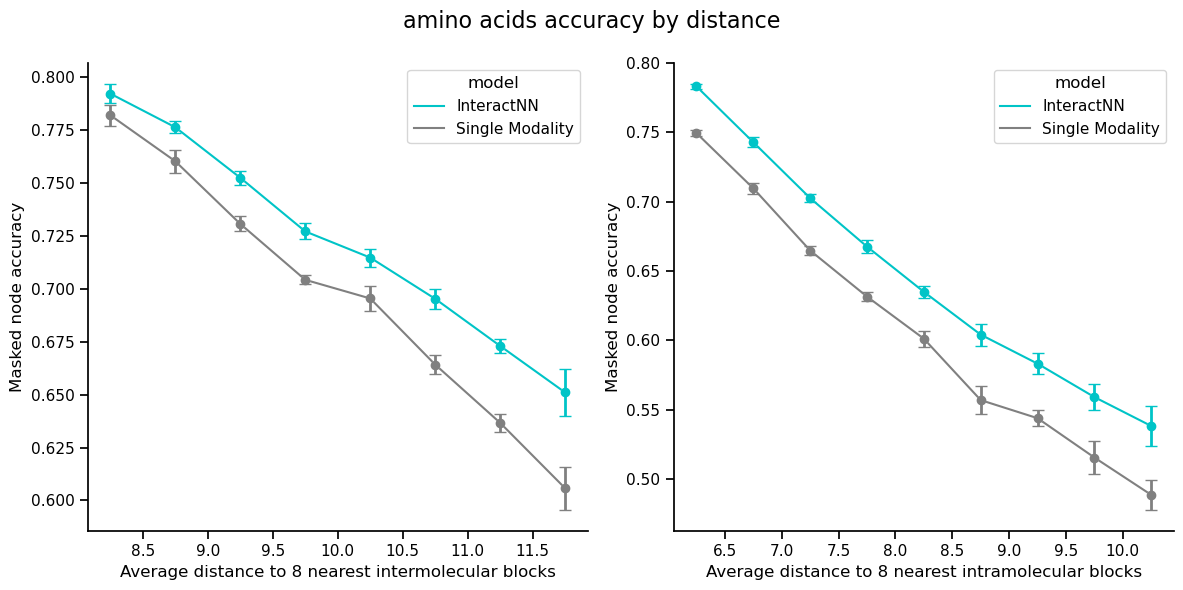

/tmp/ipykernel_294711/2397038613.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inter_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'seed'])['correct'].mean().reset_index()
/tmp/ipykernel_294711/2397038613.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inter_accuracy_per_bin = inter_accuracy_per_bin.groupby(['distance_bin_mid', 'model'])['correct'].agg(['mean', 'std']).reset_index()
/tmp/ipykernel_294711/2397038613.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beha

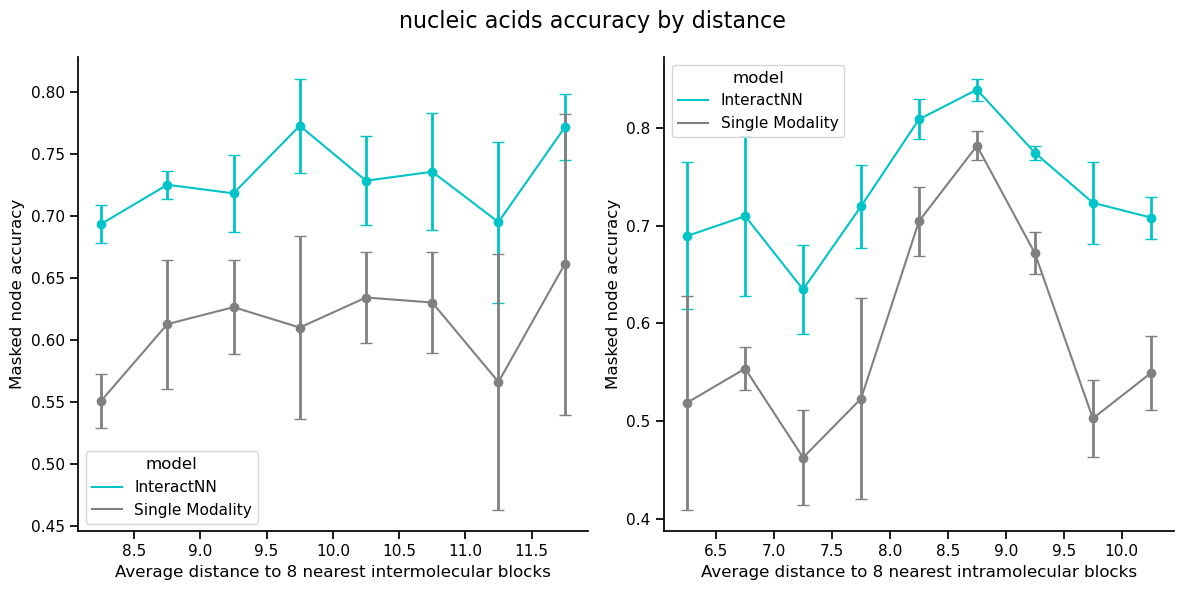

/tmp/ipykernel_294711/2397038613.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inter_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'seed'])['correct'].mean().reset_index()
/tmp/ipykernel_294711/2397038613.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inter_accuracy_per_bin = inter_accuracy_per_bin.groupby(['distance_bin_mid', 'model'])['correct'].agg(['mean', 'std']).reset_index()
/tmp/ipykernel_294711/2397038613.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beha

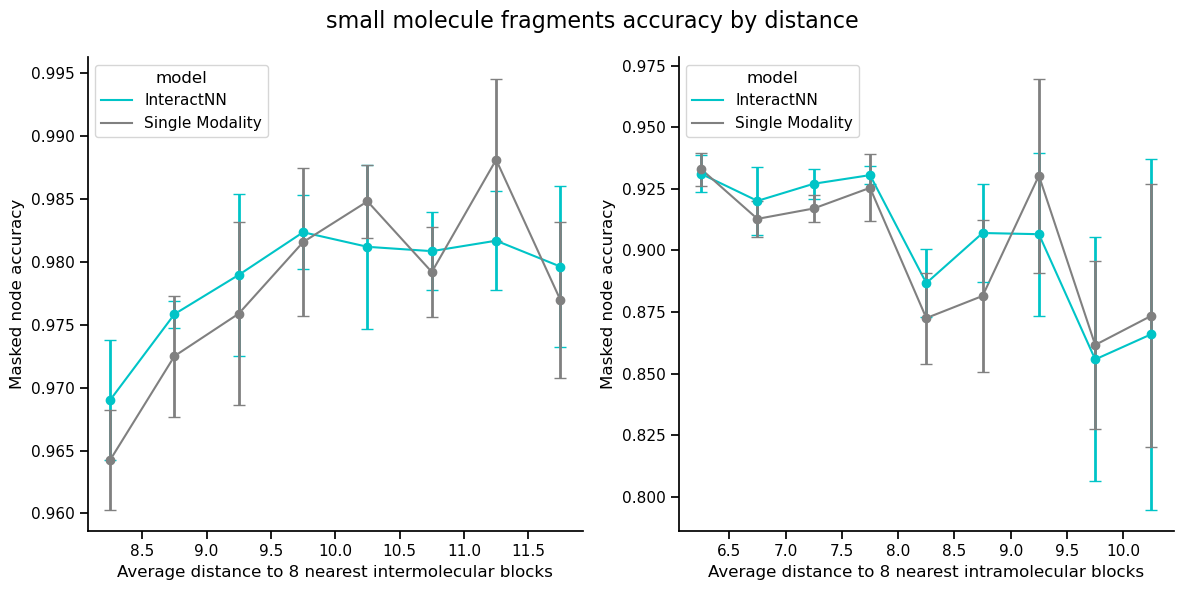

/tmp/ipykernel_294711/2397038613.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inter_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'seed'])['correct'].mean().reset_index()
/tmp/ipykernel_294711/2397038613.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inter_accuracy_per_bin = inter_accuracy_per_bin.groupby(['distance_bin_mid', 'model'])['correct'].agg(['mean', 'std']).reset_index()
/tmp/ipykernel_294711/2397038613.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beha

KeyError: 'y'

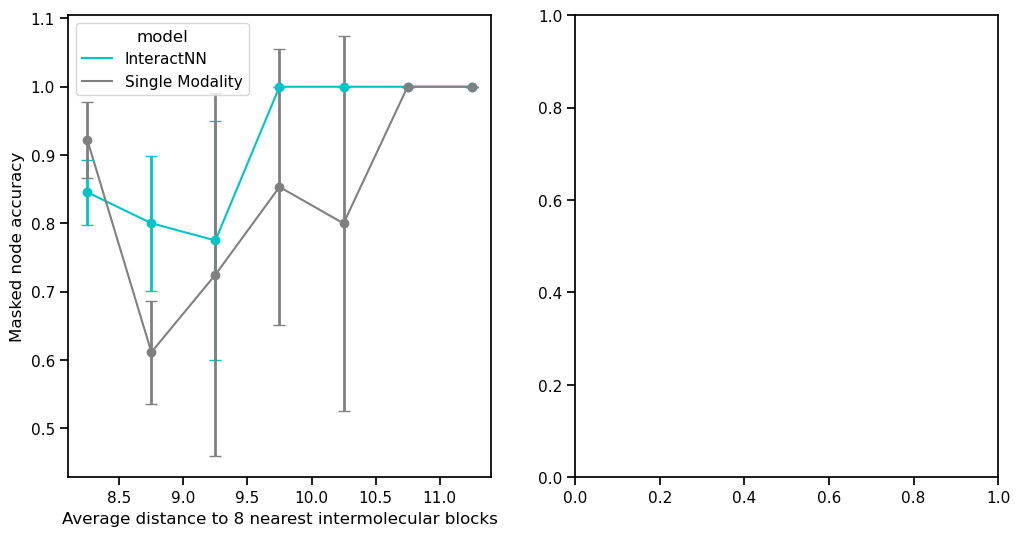

In [30]:
for chosen_modality in ['amino acids', 'nucleic acids', 'small molecule fragments', 'metal ion']:
    # Define bins for inter_distance
    bins = np.arange(8, 12.5, 0.5)
    df_clean = results_df.dropna(subset=['inter_distance'])
    df_clean = df_clean[df_clean.block_type==chosen_modality].copy()
    df_clean['distance_bin'] = pd.cut(df_clean['inter_distance'], bins=bins)
    df_clean['distance_bin_mid'] = df_clean['distance_bin'].apply(lambda x: x.mid)
    inter_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'seed'])['correct'].mean().reset_index()
    inter_accuracy_per_bin = inter_accuracy_per_bin.groupby(['distance_bin_mid', 'model'])['correct'].agg(['mean', 'std']).reset_index()
    # inter_accuracy_per_bin.columns = inter_accuracy_per_bin.columns.droplevel(1)

    # Define bins for intra_distance
    bins = np.arange(6, 11, 0.5)
    df_clean = results_df.dropna(subset=['intra_distance'])
    df_clean = df_clean[df_clean.block_type==chosen_modality].copy()
    df_clean['distance_bin'] = pd.cut(df_clean['intra_distance'], bins=bins)
    df_clean['distance_bin_mid'] = df_clean['distance_bin'].apply(lambda x: x.mid)
    intra_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'seed'])['correct'].mean().reset_index()
    intra_accuracy_per_bin = intra_accuracy_per_bin.groupby(['distance_bin_mid', 'model'])['correct'].agg(['mean', 'std']).reset_index()
    # intra_accuracy_per_bin.columns = intra_accuracy_per_bin.columns.droplevel(1)


    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    sns_plot = sns.lineplot(x='distance_bin_mid', y='mean', hue='model', data=inter_accuracy_per_bin, marker="o", ax=axes[0], palette=model_custom_colors)
    for i, model in enumerate(inter_accuracy_per_bin['model'].unique()):
        model_data = inter_accuracy_per_bin[inter_accuracy_per_bin['model'] == model]
        line_color = sns_plot.get_lines()[i].get_color()
        axes[0].errorbar(x=model_data['distance_bin_mid'], y=model_data['mean'], yerr=model_data['std'], fmt='o', capsize=4, elinewidth=2, color=line_color)
    axes[0].set_xlabel('Average distance to 8 nearest intermolecular blocks')
    axes[0].set_ylabel('Masked node accuracy')

    sns_plot = sns.lineplot(x='distance_bin_mid', y='mean', hue='model', data=intra_accuracy_per_bin, marker="o", ax=axes[1], palette=model_custom_colors)
    for i, model in enumerate(intra_accuracy_per_bin['model'].unique()):
        model_data = intra_accuracy_per_bin[intra_accuracy_per_bin['model'] == model]
        line_color = sns_plot.get_lines()[i].get_color()
        axes[1].errorbar(x=model_data['distance_bin_mid'], y=model_data['mean'], yerr=model_data['std'], fmt='o', capsize=4, elinewidth=2, color=line_color)
    axes[1].set_xlabel('Average distance to 8 nearest intramolecular blocks')
    axes[1].set_ylabel('Masked node accuracy')

    sns.despine()
    plt.subplots_adjust(top=0.9)
    plt.suptitle(f'{chosen_modality} accuracy by distance', fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
for chosen_modality in ['amino acids', 'nucleic acids']:
    # Define bins for inter_distance
    bins = np.arange(8, 12.5, 0.5)
    df_clean = results_df.dropna(subset=['inter_distance'])
    df_clean = df_clean[(df_clean.block_type==chosen_modality) & df_clean.modality.isin(['PRNA', 'PDNA'])].copy()
    df_clean['distance_bin'] = pd.cut(df_clean['inter_distance'], bins=bins)
    df_clean['distance_bin_mid'] = df_clean['distance_bin'].apply(lambda x: x.mid)
    inter_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'seed'])['correct'].mean().reset_index()
    inter_accuracy_per_bin = inter_accuracy_per_bin.groupby(['distance_bin_mid', 'model'])['correct'].agg(['mean', 'std']).reset_index()
    # inter_accuracy_per_bin.columns = inter_accuracy_per_bin.columns.droplevel(1)

    # Define bins for intra_distance
    bins = np.arange(6, 11, 0.5)
    df_clean = results_df.dropna(subset=['intra_distance'])
    df_clean = df_clean[(df_clean.block_type==chosen_modality) & df_clean.modality.isin(['PRNA', 'PDNA'])].copy()
    df_clean['distance_bin'] = pd.cut(df_clean['intra_distance'], bins=bins)
    df_clean['distance_bin_mid'] = df_clean['distance_bin'].apply(lambda x: x.mid)
    intra_accuracy_per_bin = df_clean.groupby(['distance_bin_mid', 'model', 'seed'])['correct'].mean().reset_index()
    intra_accuracy_per_bin = intra_accuracy_per_bin.groupby(['distance_bin_mid', 'model'])['correct'].agg(['mean', 'std']).reset_index()
    # intra_accuracy_per_bin.columns = intra_accuracy_per_bin.columns.droplevel(1)


    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    sns_plot = sns.lineplot(x='distance_bin_mid', y='mean', hue='model', data=inter_accuracy_per_bin, marker="o", ax=axes[0], palette=model_custom_colors)
    for i, model in enumerate(inter_accuracy_per_bin['model'].unique()):
        model_data = inter_accuracy_per_bin[inter_accuracy_per_bin['model'] == model]
        line_color = sns_plot.get_lines()[i].get_color()
        axes[0].errorbar(x=model_data['distance_bin_mid'], y=model_data['mean'], yerr=model_data['std'], fmt='o', capsize=4, elinewidth=2, color=line_color)
    axes[0].set_xlabel('Average distance to 8 nearest intermolecular blocks')
    axes[0].set_ylabel('Masked node accuracy')

    sns_plot = sns.lineplot(x='distance_bin_mid', y='mean', hue='model', data=intra_accuracy_per_bin, marker="o", ax=axes[1], palette=model_custom_colors)
    for i, model in enumerate(intra_accuracy_per_bin['model'].unique()):
        model_data = intra_accuracy_per_bin[intra_accuracy_per_bin['model'] == model]
        line_color = sns_plot.get_lines()[i].get_color()
        axes[1].errorbar(x=model_data['distance_bin_mid'], y=model_data['mean'], yerr=model_data['std'], fmt='o', capsize=4, elinewidth=2, color=line_color)
    axes[1].set_xlabel('Average distance to 8 nearest intramolecular blocks')
    axes[1].set_ylabel('Masked node accuracy')

    sns.despine()
    plt.subplots_adjust(top=0.9)
    plt.suptitle(f'{chosen_modality} accuracy by distance', fontsize=16)
    plt.tight_layout()
    plt.show()